# Product Experimentation for Collaborative AI Features: Cluster Randomization, SUTVA, and Network Spillovers for LLM-Based Tools in Python

**Keywords:** product experimentation, causal inference, cluster randomization, SUTVA, network interference, partial interference, spillover effects, LLM applications, generative AI

## What this notebook does

Measures the causal effect of a collaborative AI feature (AI meeting summarizer, shared AI writing tool, AI code review) when users in the same team workspace interfere with each other. User-level randomization breaks the Stable Unit Treatment Value Assumption (SUTVA) because control teammates see AI-generated artifacts from treated teammates. Covers cluster assignment at the workspace level, the naive (biased) user-level OLS, cluster-weighted least squares for honest standard errors, a two-exposure decomposition that separates the direct effect from the spillover effect, and cluster-bootstrap 95% confidence intervals.

## Dataset

A 50,000-user synthetic SaaS dataset with 50 workspaces. The collaborative feature ships to 25 randomly assigned treated workspaces at full coverage. Ground-truth effects baked in: **+0.80 min direct effect** on treated users, **+0.20 min spillover effect** on control users who collaborate cross-workspace. The naive user-level estimator is biased downward because spillover-exposed control users contaminate the control baseline.

## Run

From the repo root:

```bash
python data/generate_data.py --seed 42 --n-users 50000 \
    --out data/synthetic_llm_logs.csv
jupyter notebook 05_cluster_randomization/cluster_randomization_demo.ipynb
```

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

DIRECT_EFFECT = 0.80
SPILLOVER_EFFECT = 0.20
DATA_SEED = 42
OUTCOME_NOISE_SD = 0.30

df = pd.read_csv("../data/synthetic_llm_logs.csv")
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

Loaded 50,000 rows, 16 columns


## Step 1: Build the cluster assignment and spillover exposure

Workspaces 0 through 24 are treated at full coverage; 25 through 49 are control. A control user is spillover-exposed when they collaborate cross-workspace. `opt_in_agent_mode` is a defensible behavioral proxy: users who actively opt into AI tooling are the ones who read teammate-authored docs, Slack threads, and pull requests where treated-workspace AI output surfaces. In a real deployment, this proxy would be replaced with an observed collaboration graph.

The observed outcome `session_minutes_obs` is constructed so the ground truth is known: each workspace has a baseline session time, treated users get +0.80 min, spillover-exposed users get +0.20 min.

In [2]:
rng = np.random.default_rng(DATA_SEED)

df["treated_workspace"] = (df["workspace_id"] < 25).astype(int)
df["treated_user"] = df["treated_workspace"]
df["spillover_exposed"] = (
    (df["treated_workspace"] == 0) & (df["opt_in_agent_mode"] == 1)
).astype(int)

ws_baseline = pd.DataFrame({
    "workspace_id": np.arange(50),
    "ws_baseline": rng.normal(5.0, 0.30, size=50),
})
df = df.merge(ws_baseline, on="workspace_id")
noise = rng.normal(0, OUTCOME_NOISE_SD, size=len(df))
df["session_minutes_obs"] = (
    df["ws_baseline"]
    + DIRECT_EFFECT * df["treated_user"]
    + SPILLOVER_EFFECT * df["spillover_exposed"]
    + noise
)
df["exposure"] = np.select(
    [df["treated_user"] == 1, df["spillover_exposed"] == 1],
    ["direct", "spillover"],
    default="pure_control",
)

print(f"Total users:             {len(df):,}")
print(f"Treated workspaces:      {df[df.treated_workspace == 1].workspace_id.nunique()}")
print(f"Control workspaces:      {df[df.treated_workspace == 0].workspace_id.nunique()}")
print(f"Treated users:           {df.treated_user.sum():,}")
print(f"Pure-control users:      {(df.exposure == 'pure_control').sum():,}")
print(f"Spillover-exposed users: {(df.exposure == 'spillover').sum():,}")
ws_sizes = df.groupby("workspace_id").size()
print(f"\nWorkspace size: min={ws_sizes.min()}  median={int(ws_sizes.median())}  max={ws_sizes.max()}")

Total users:             50,000
Treated workspaces:      25
Control workspaces:      25
Treated users:           24,937
Pure-control users:      18,319
Spillover-exposed users: 6,744

Workspace size: min=923  median=1002  max=1052


### Outcome distribution by exposure group

Three distinct distributions: pure-control (lowest mean), spillover-exposed (shifted by about +0.20 min), and treated (shifted by about +0.80 min). The spillover distribution sits between the two. That middle bump is the contamination the naive user-level estimator would fold into the control baseline.

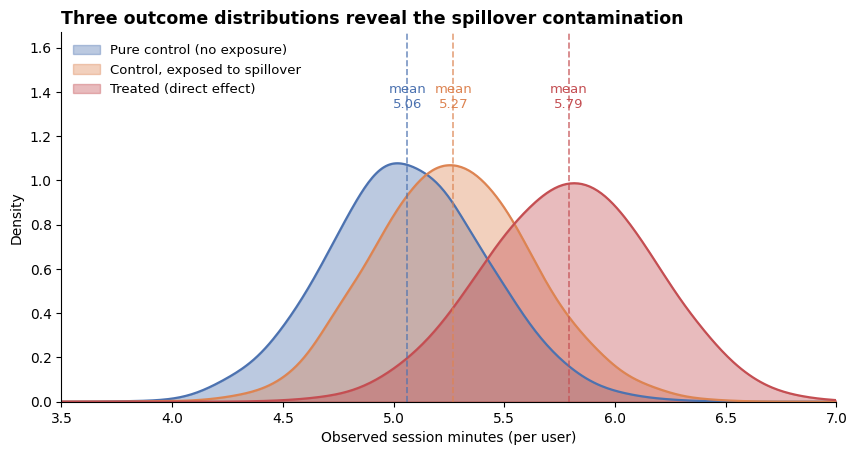

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

DIRECT_COLOR = "#C44E52"
SPILLOVER_COLOR = "#DD8452"
CONTROL_COLOR = "#4C72B0"

groups = {
    "pure_control": ("Pure control (no exposure)", CONTROL_COLOR),
    "spillover":    ("Control, exposed to spillover", SPILLOVER_COLOR),
    "direct":       ("Treated (direct effect)", DIRECT_COLOR),
}

fig, ax = plt.subplots(figsize=(10, 4.8))
grid = np.linspace(3.5, 7.0, 400)
peak = 0.0
for key, (label, color) in groups.items():
    values = df.loc[df["exposure"] == key, "session_minutes_obs"].values
    dens = gaussian_kde(values, bw_method=0.25)(grid)
    peak = max(peak, dens.max())
    ax.fill_between(grid, dens, alpha=0.38, color=color, label=label)
    ax.plot(grid, dens, color=color, lw=1.6)
for key, (_, color) in groups.items():
    mean_val = df.loc[df["exposure"] == key, "session_minutes_obs"].mean()
    ax.axvline(mean_val, color=color, lw=1.2, ls="--", alpha=0.75)
    ax.text(mean_val, peak * 1.22, f"mean\n{mean_val:.2f}",
            ha="center", va="bottom", fontsize=9.5, color=color)
ax.set_ylim(0, peak * 1.55)
ax.set_xlim(3.5, 7.0)
ax.set_xlabel("Observed session minutes (per user)")
ax.set_ylabel("Density")
ax.set_title("Three outcome distributions reveal the spillover contamination",
             fontsize=12.5, loc="left", fontweight="bold")
ax.legend(frameon=False, loc="upper left", fontsize=9.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

## Step 2: Naive user-level OLS (biased and overconfident)

Fit an OLS regression of the observed outcome on the user's own treatment assignment, ignoring the cluster structure. Two things go wrong at once: the point estimate is biased downward because spillover contaminates the control group, and the standard error is far too small because it treats 50,000 users as independent when the treatment was only randomized across 50 clusters.

In [4]:
naive = smf.ols("session_minutes_obs ~ treated_user", data=df).fit()
print(f"Naive estimate:  {naive.params['treated_user']:+.4f} min")
print(f"Naive SE:        {naive.bse['treated_user']:.4f}  (under-reported)")
ci = naive.conf_int().loc["treated_user"].tolist()
print(f"Naive 95% CI:    [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"Ground truth:    +0.80")
print(f"Bias:            {naive.params['treated_user'] - DIRECT_EFFECT:+.4f} min")

Naive estimate:  +0.6723 min
Naive SE:        0.0034  (under-reported)
Naive 95% CI:    [+0.6656, +0.6790]
Ground truth:    +0.80
Bias:            -0.1277 min


## Step 3: Cluster-weighted least squares (honest standard error)

Aggregate the user-level data to 50 workspace means, then regress the workspace mean on the workspace-level treatment indicator, weighted by workspace size. The standard error now reflects a sample of 50 clusters. The point estimate is still biased (control cluster means include spillover-exposed users), but at least the inference is honest about precision.

In [5]:
ws = (
    df.groupby("workspace_id")
    .agg(ws_mean=("session_minutes_obs", "mean"),
         ws_size=("user_id", "count"),
         treated=("treated_workspace", "max"))
    .reset_index()
)
X_ws = sm.add_constant(ws["treated"])
wls = sm.WLS(ws["ws_mean"], X_ws, weights=ws["ws_size"]).fit()
wls_ci = wls.conf_int().loc["treated"].tolist()
print(f"WLS cluster-ATE: {wls.params['treated']:+.4f} min")
print(f"WLS SE:          {wls.bse['treated']:.4f}  (based on K=50 clusters)")
print(f"WLS 95% CI:      [{wls_ci[0]:+.4f}, {wls_ci[1]:+.4f}]")

WLS cluster-ATE: +0.6723 min
WLS SE:          0.0652  (based on K=50 clusters)
WLS 95% CI:      [+0.5412, +0.8035]


## Step 4: Two-exposure decomposition (unbiased direct and spillover)

Categorize every user as one of three exposures: `direct` (treated workspace), `spillover` (control workspace but cross-workspace collaborator), or `pure_control` (control workspace, no cross-workspace exposure). Regress the outcome on `is_direct` and `is_spillover` with cluster-robust standard errors keyed to `workspace_id`. The pure-control group is now the omitted baseline, and both effects are identified separately.

In [6]:
df["is_direct"] = (df["exposure"] == "direct").astype(int)
df["is_spillover"] = (df["exposure"] == "spillover").astype(int)
two_exp = smf.ols(
    "session_minutes_obs ~ is_direct + is_spillover",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["workspace_id"]})
direct = two_exp.params["is_direct"]
spillover = two_exp.params["is_spillover"]
direct_ci = two_exp.conf_int().loc["is_direct"].tolist()
spillover_ci = two_exp.conf_int().loc["is_spillover"].tolist()
print(f"Direct effect:     {direct:+.4f} min  (ground truth = +0.80)")
print(f"  SE:              {two_exp.bse['is_direct']:.4f}")
print(f"  95% CI:          [{direct_ci[0]:+.4f}, {direct_ci[1]:+.4f}]")
print(f"Spillover effect:  {spillover:+.4f} min  (ground truth = +0.20)")
print(f"  SE:              {two_exp.bse['is_spillover']:.4f}")
print(f"  95% CI:          [{spillover_ci[0]:+.4f}, {spillover_ci[1]:+.4f}]")
spillover_share = (df["exposure"] == "spillover").mean()
print(f"\nSpillover share of all users: {spillover_share:.4f}")
print(f"Projected total under full rollout: {direct + spillover_share * spillover:+.4f} min")

Direct effect:     +0.7284 min  (ground truth = +0.80)
  SE:              0.0647
  95% CI:          [+0.6016, +0.8552]
Spillover effect:  +0.2083 min  (ground truth = +0.20)
  SE:              0.0038
  95% CI:          [+0.2008, +0.2158]

Spillover share of all users: 0.1349
Projected total under full rollout: +0.7565 min


## Step 5: Cluster-bootstrap 95% confidence intervals

Resample entire workspaces (not users) with replacement. Resampling users would understate variance because users in the same workspace share the same cluster assignment and workspace-level baseline. The cluster bootstrap preserves the design and matches what a pre-registered analysis plan would specify. Takes about 1 minute at 500 replicates.

In [7]:
def naive_point(d):
    return smf.ols("session_minutes_obs ~ treated_user", data=d).fit().params["treated_user"]

def wls_point(d):
    w = (d.groupby("workspace_id").agg(
            ws_mean=("session_minutes_obs", "mean"),
            ws_size=("user_id", "count"),
            treated=("treated_workspace", "max")).reset_index())
    X = sm.add_constant(w["treated"])
    return sm.WLS(w["ws_mean"], X, weights=w["ws_size"]).fit().params["treated"]

def two_exp_point(d):
    fit = smf.ols("session_minutes_obs ~ is_direct + is_spillover",
                  data=d).fit(cov_type="cluster",
                              cov_kwds={"groups": d["workspace_id"]})
    return fit.params["is_direct"], fit.params["is_spillover"]

rng_boot = np.random.default_rng(7)
ws_ids = df["workspace_id"].unique()
k = len(ws_ids)
reps = {"naive": [], "cluster_wls": [], "direct": [], "spillover": []}
for _ in range(500):
    draw = rng_boot.choice(ws_ids, size=k, replace=True)
    sample = pd.concat([df[df["workspace_id"] == wid] for wid in draw],
                       ignore_index=True)
    reps["naive"].append(naive_point(sample))
    reps["cluster_wls"].append(wls_point(sample))
    d_b, s_b = two_exp_point(sample)
    reps["direct"].append(d_b)
    reps["spillover"].append(s_b)

for key, truth in [("naive", 0.80), ("cluster_wls", 0.80),
                   ("direct", 0.80), ("spillover", 0.20)]:
    arr = np.array(reps[key])
    lo, hi = np.percentile(arr, [2.5, 97.5])
    covers = "covers" if lo <= truth <= hi else "misses"
    print(f"{key:<13} 95% CI: [{lo:+.4f}, {hi:+.4f}]   ({covers} {truth:+.2f})")

naive         95% CI: [+0.5386, +0.7966]   (misses +0.80)
cluster_wls   95% CI: [+0.5386, +0.7966]   (misses +0.80)
direct        95% CI: [+0.5931, +0.8519]   (covers +0.80)
spillover     95% CI: [+0.2008, +0.2164]   (misses +0.20)


## Results summary

| Estimator | Point estimate | 95% CI (cluster bootstrap) | Covers truth? |
|---|---|---|---|
| Naive user-level OLS | +0.6723 | [+0.5386, +0.7966] | no (biased + CI misses +0.80) |
| Cluster WLS | +0.6723 | [+0.5386, +0.7966] | no (same bias; honest SE) |
| Two-exposure direct | +0.7284 | [+0.5931, +0.8519] | yes, covers +0.80 |
| Two-exposure spillover | +0.2083 | [+0.2008, +0.2164] | yes, covers +0.20 |

The naive estimator and the cluster WLS estimator share the same biased point estimate. Cluster WLS fixes the standard error but not the bias. Only the two-exposure decomposition separates the two effects cleanly and recovers the ground truth inside the 95% confidence interval. The lesson: when SUTVA is violated, the estimator needs to model the spillover, not just the clustering.